<a href="https://colab.research.google.com/github/NooraZhang/IBD-diet-and-inflammation-analysis/blob/main/IBDMDB_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1 style="font-size: 42px;">Dietary Intake and Inflammatory Activity in IBD</h1>

## Research Question
Is dietary intake associated with intestinal inflammation severity, as measured by fecal calprotectin?

## Data Source
The metadata were obtained from the Inflammatory Bowel Disease Multi-omics Database (IBDMDB). Each participant was followed longitudinally, so one participant may contribute observations from multiple visits.

# IBDMDB

IBDMDB is a dataset that contains information about the patient’s food intake, microbiome compositions, patient’s personal information and the inflammation indexes. It is used to record the status and severity of inflammation for different IBD patients.

#Import the file


In [2]:
import pandas as pd

DATA_URL = (
    "https://g-227ca.190ebd.75bc.data.globus.org/"
    "ibdmdb/metadata/hmp2_metadata_2018-08-20.csv"
)

df_raw = pd.read_csv(DATA_URL, low_memory=False)

print("Raw dataset shape:", df_raw.shape)
assert df_raw.shape == (5533, 490), \
    f"Unexpected dataset shape: {df_raw.shape}"

Raw dataset shape: (5533, 490)


In [3]:
df = df_raw.copy()
print(df.shape)

(5533, 490)


# Eliminate the unuseful variables

The raw IBDMDB metadata contained 5,533 rows and 490 columns. I selected 31 variables relevant to the research question. These included participant characteristics, medication use, dietary intake variables, diagnosis, and inflammation measurements. Fecal calprotectin was selected as the main measure of intestinal inflammation because it reflects inflammation in the gastrointestinal tract and it contains fewer missing values than other inflammation markers.

In [4]:
import pandas as pd
df = df_raw.copy()

columns_to_keep = [
    'Participant ID', 'week_num', 'diagnosis', 'sex', 'race', 'BMI',
    'Age at diagnosis', 'Antibiotics',
    'Immunosuppressants (e.g. oral corticosteroids)',
    'fecalcal_ng_ml', 'fecalcal', 'is_inflamed', 'hbi', 'sccai',
    'CRP (mg/L)',
    'Fruits (no juice) (Apples, raisins, bananas, oranges, strawberries, blueberries',
    'Vegetables (salad, tomatoes, onions, greens, carrots, peppers, green beans, etc)',
    'Red meat (beef, hamburger, pork, lamb)',
    'White meat (chicken, turkey, etc.)',
    'Fish (fish nuggets, breaded fish, fish cakes, salmon, tuna, etc.)',
    'Whole grains (wheat, oats, brown rice, rye, quinoa, wheat bread, wheat pasta)',
    'Starch (white rice, bread, pizza, potatoes, yams, cereals, pancakes, etc.)',
    'Dairy (milk, cream, ice cream, cheese, cream cheese)',
    'Sweets (pies, jam, chocolate, cake, cookies, etc.)',
    'Yogurt or other foods containing active bacterial cultures (kefir, sauerkraut)',
    'Beans (tofu, soy, soy burgers, lentils, Mexican beans, lima beans etc)',
    'Eggs',
    'Processed meat (other red or white meat such as lunch meat, ham, salami, bologna',
    'Alcohol (beer, brandy, spirits, hard liquor, wine, aperitif, etc.)',
    'Water',
    'Soft drinks, tea or coffee with sugar (corn syrup, maple syrup, cane sugar, etc)'
]

df = df[columns_to_keep]
print(df.shape)
print(df.head())

(5533, 31)
  Participant ID  week_num diagnosis     sex   race  BMI  Age at diagnosis  \
0          C3001       2.0        CD  Female  White  NaN              28.0   
1          C3001       2.0        CD  Female  White  NaN              28.0   
2          C3002       0.0        CD  Female  White  NaN              47.0   
3          C3002       0.0        CD  Female  White  NaN              47.0   
4          C3002       0.0        CD  Female  White  NaN              47.0   

  Antibiotics Immunosuppressants (e.g. oral corticosteroids)  fecalcal_ng_ml  \
0          No                                             No             NaN   
1          No                                             No             NaN   
2          No                                             No             NaN   
3          No                                             No             NaN   
4          No                                             No             NaN   

   ...  \
0  ...   
1  ...   
2  ...   

# Filter out the samples with no data of fecal calprotectin


Among the 5,533 records, 1,883 had a valid fecal calprotectin value. Records without fecal calprotectin were removed because they could not be used to examine the relationship between diet and inflammation.

In [5]:
inflammation_vars = ['fecalcal', 'fecalcal_ng_ml', 'is_inflamed', 'hbi', 'sccai', 'CRP (mg/L)']

for var in inflammation_vars:
    total = len(df)
    missing = df[var].isna().sum()
    valid = total - missing
    pct_missing = missing/total*100
    print(f"{var}: {valid} valid ({pct_missing:.1f}% missing)")

fecalcal: 1883 valid (66.0% missing)
fecalcal_ng_ml: 121 valid (97.8% missing)
is_inflamed: 881 valid (84.1% missing)
hbi: 2145 valid (61.2% missing)
sccai: 1335 valid (75.9% missing)
CRP (mg/L): 669 valid (87.9% missing)


In [6]:

df_clean2 = df[df['fecalcal'].notna()]
print(df_clean2.shape)
print(df_clean2['diagnosis'].value_counts())
print(df_clean2['fecalcal'].head(10))

(1883, 31)
diagnosis
CD        928
UC        512
nonIBD    443
Name: count, dtype: int64
522    193.89000
523     61.34000
524    115.27000
525     23.20350
526     37.17836
527     48.90000
528    179.22000
529     54.33000
530     15.97901
531     14.51068
Name: fecalcal, dtype: float64


# Print the number of missing data for each variable

In [7]:
# 用fecalcal过滤
df_clean = df[df['fecalcal'].notna()].copy()

# 检查missing values
print(df_clean.isnull().sum())

Participant ID                                                                         0
week_num                                                                               0
diagnosis                                                                              0
sex                                                                                    0
race                                                                                   0
BMI                                                                                 1883
Age at diagnosis                                                                     458
Antibiotics                                                                            0
Immunosuppressants (e.g. oral corticosteroids)                                         0
fecalcal_ng_ml                                                                      1883
fecalcal                                                                               0
is_inflamed          

# Delete the variables with no data


Variables that were completely missing after this filtering step, including BMI, fecalcal_ng_ml, is_inflamed, and CRP, were also removed.

Records with missing values in any of the 16 dietary variables were excluded. After this complete-case filtering, the analysis contained 1,739 records.

In [8]:

df_clean = df_clean.drop(columns=['BMI', 'fecalcal_ng_ml', 'is_inflamed', 'CRP (mg/L)'])


dietary_cols = [
    'Fruits (no juice) (Apples, raisins, bananas, oranges, strawberries, blueberries',
    'Vegetables (salad, tomatoes, onions, greens, carrots, peppers, green beans, etc)',
    'Red meat (beef, hamburger, pork, lamb)',
    'White meat (chicken, turkey, etc.)',
    'Fish (fish nuggets, breaded fish, fish cakes, salmon, tuna, etc.)',
    'Whole grains (wheat, oats, brown rice, rye, quinoa, wheat bread, wheat pasta)',
    'Starch (white rice, bread, pizza, potatoes, yams, cereals, pancakes, etc.)',
    'Dairy (milk, cream, ice cream, cheese, cream cheese)',
    'Sweets (pies, jam, chocolate, cake, cookies, etc.)',
    'Yogurt or other foods containing active bacterial cultures (kefir, sauerkraut)',
    'Beans (tofu, soy, soy burgers, lentils, Mexican beans, lima beans etc)',
    'Eggs',
    'Processed meat (other red or white meat such as lunch meat, ham, salami, bologna',
    'Alcohol (beer, brandy, spirits, hard liquor, wine, aperitif, etc.)',
    'Water',
    'Soft drinks, tea or coffee with sugar (corn syrup, maple syrup, cane sugar, etc)'
]

df_clean = df_clean.dropna(subset=dietary_cols)
print(df_clean.shape)
print(df_clean['diagnosis'].value_counts())

(1739, 27)
diagnosis
CD        858
UC        468
nonIBD    413
Name: count, dtype: int64


# Visualization of the distribution of fecalcal

count    1739.000000
mean      116.573963
std       115.177453
min         3.450000
25%        16.733720
50%        54.740000
75%       212.670000
max       493.700000
Name: fecalcal, dtype: float64


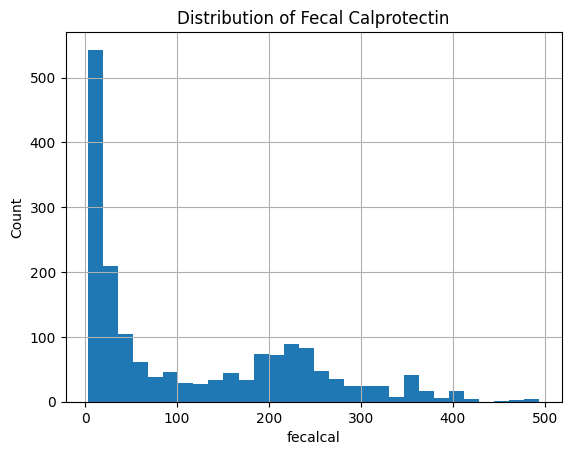

In [9]:
print(df_clean['fecalcal'].describe())

import matplotlib.pyplot as plt
df_clean['fecalcal'].hist(bins=30)
plt.title('Distribution of Fecal Calprotectin')
plt.xlabel('fecalcal')
plt.ylabel('Count')
plt.show()

Fecal calprotectin had a right-skewed distribution. The median value was 54.74 μg/g, while the mean was 116.57 μg/g. This difference indicates that a smaller number of records with high fecal calprotectin values increased the mean. The observed values ranged from 3.45 to 493.70 μg/g.

# Log-transformed visualization of the distribution of fecalcal

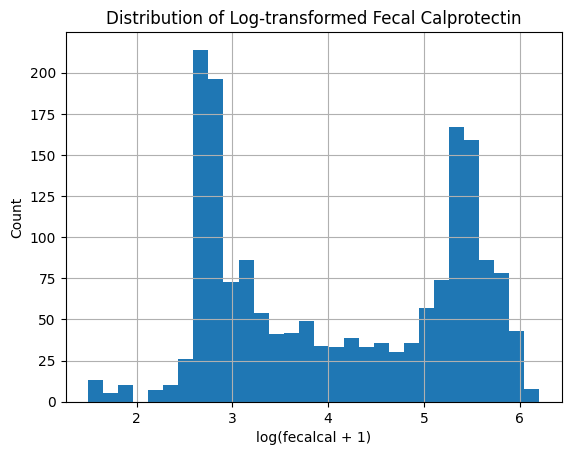

In [10]:
import numpy as np

# Log transformation
df_clean['fecalcal_log'] = np.log(df_clean['fecalcal'] + 1)


df_clean['fecalcal_log'].hist(bins=30)
plt.title('Distribution of Log-transformed Fecal Calprotectin')
plt.xlabel('log(fecalcal + 1)')
plt.ylabel('Count')
plt.show()

A log-transformed graph is generated to show the distribution of fecal calprotectin more clearly. It shows that there are two peak values. The first peak value would be participants who have low level of fecal calprotectin, while the second one may indicate the participants who are experiencing a flare-up period of IBD.

#Result of the Spearman statistical test

---



Dietary intake was recorded as an ordinal categorical variable. I converted the categories into numerical scores from 0 to 4 according to their order.

Spearman correlation test was carried out in order to investigate the assosiation between food and fecal calprotectin. Correlation is used to show the relationship between food and fecal calprotectin. A positive value indicates that the intake of the food is associated with increased level of fecal calprotectin, while a negative value indicates that the intake of the food is associated with a decreased level of fecal calprotectin.

P-value is used to indicate whether the correlation between food and fecal calprotecitn is statistically significant (p < 0.05：statistically significant,
p ≥ 0.05：not statistically significant).

In [30]:
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
import pandas as pd
import numpy as np

# 每次运行时清空旧结果
results = []

for col in dietary_cols:
    temp = df_clean[[col, 'fecalcal']].dropna()

    corr, pval = spearmanr(
        temp[col],
        temp['fecalcal']
    )

    results.append({
        'Food': col,
        'Correlation': corr,
        'P-value': pval
    })

# 重新创建，而不是追加到旧表
results_df = pd.DataFrame(results)

# Bonferroni correction（共16次检验）
results_df['Adjusted P-value'] = multipletests(
    results_df['P-value'],
    method='bonferroni'
)[1]

results_df['Significant'] = np.where(
    results_df['Adjusted P-value'] < 0.05,
    'Yes',
    'No'
)

results_df = results_df.sort_values(
    'Correlation',
    ascending=False
).reset_index(drop=True)

print("Number of tests:", len(results_df))

display(
    results_df.style.format({
        'Correlation': '{:.3f}',
        'P-value': '{:.4g}',
        'Adjusted P-value': '{:.4g}'
    })
)

Number of tests: 16


,Food,Correlation,P-value,Adjusted P-value,Significant
0,"Processed meat (other red or white meat such as lunch meat, ham, salami, bologna",0.038,0.1142,1,No
1,"Soft drinks, tea or coffee with sugar (corn syrup, maple syrup, cane sugar, etc)",0.036,0.1377,1,No
2,"Fish (fish nuggets, breaded fish, fish cakes, salmon, tuna, etc.)",-0.025,0.2988,1,No
3,Eggs,-0.035,0.1495,1,No
4,"Dairy (milk, cream, ice cream, cheese, cream cheese)",-0.037,0.1194,1,No
5,"Sweets (pies, jam, chocolate, cake, cookies, etc.)",-0.064,0.007388,0.1182,No
6,"White meat (chicken, turkey, etc.)",-0.078,0.001066,0.01705,Yes
7,"Whole grains (wheat, oats, brown rice, rye, quinoa, wheat bread, wheat pasta)",-0.092,0.0001179,0.001887,Yes
8,"Starch (white rice, bread, pizza, potatoes, yams, cereals, pancakes, etc.)",-0.110,4.646e-06,7.433e-05,Yes
9,"Beans (tofu, soy, soy burgers, lentils, Mexican beans, lima beans etc)",-0.131,4.066e-08,6.505e-07,Yes


# Visualization of the Spearman Correlation Results (Only Dietary Variables Significantly Associated with Fecal Calprotectin Are Included)

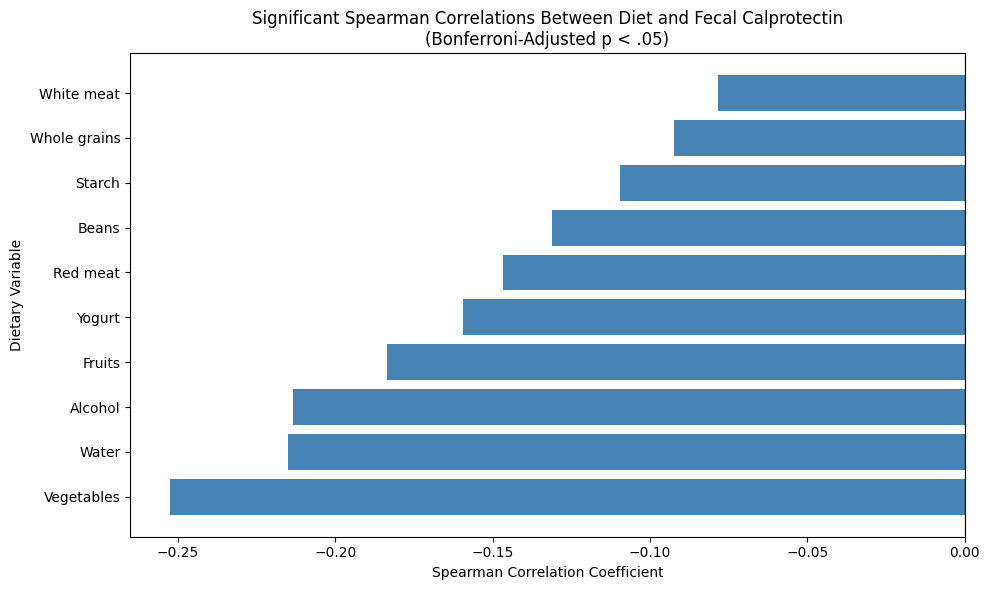

In [32]:
plt.figure(figsize=(10, 6))

colors = [
    "tomato" if value > 0 else "steelblue"
    for value in sig_results["Correlation"]
]

plt.barh(
    sig_results["Food_short"],
    sig_results["Correlation"],
    color=colors
)

plt.axvline(0, color="black", linewidth=0.8)

plt.title(
    "Significant Spearman Correlations Between Diet and Fecal Calprotectin\n"
    "(Bonferroni-Adjusted p < .05)"
)

plt.xlabel("Spearman Correlation Coefficient")
plt.ylabel("Dietary Variable")
plt.tight_layout()
plt.show()

# Group the samples into high inflammation level，gray zone and low inflammation level

The samples were categorized into three groups based on the value of fecal calprotectin: low inflammation (<50 μg/g), gray zone (50–250 μg/g), and high inflammation (>250 μg/g).

In [13]:
import numpy as np

df_clean["inflammation_level"] = np.select(
    [
        df_clean["fecalcal"] < 50,
        (df_clean["fecalcal"] >= 50) &
        (df_clean["fecalcal"] <= 250),
        df_clean["fecalcal"] > 250
    ],
    [
        "Low",
        "Gray Zone",
        "High"
    ],
    default="Missing"
)


group_order = ["Low", "Gray Zone", "High"]

df_clean["inflammation_level"] = pd.Categorical(
    df_clean["inflammation_level"],
    categories=group_order,
    ordered=True
)

print(df_clean["inflammation_level"].value_counts().sort_index())

inflammation_level
Low          842
Gray Zone    643
High         254
Name: count, dtype: int64


## Compare Mean Dietary Frequency Scores Across Inflammation Groups

This score shows how frequently each food was consumed, on average, within each inflammation group.

In [14]:
# Calculate mean dietary frequency scores for each group
diet_by_inflammation = (
    df_clean
    .dropna(subset=["inflammation_level"])
    .groupby(
        "inflammation_level",
        observed=True
    )[dietary_cols]
    .mean()
    .reindex(group_order)
    .round(2)
)

print(diet_by_inflammation)

                    Red meat (beef, hamburger, pork, lamb)  \
inflammation_level                                           
Low                                                   1.83   
Gray Zone                                             1.59   
High                                                  1.44   

                    Fish (fish nuggets, breaded fish, fish cakes, salmon, tuna, etc.)  \
inflammation_level                                                                      
Low                                                              0.73                   
Gray Zone                                                        0.80                   
High                                                             0.59                   

                    Vegetables (salad, tomatoes, onions, greens, carrots, peppers, green beans, etc)  \
inflammation_level                                                                                     
Low                                

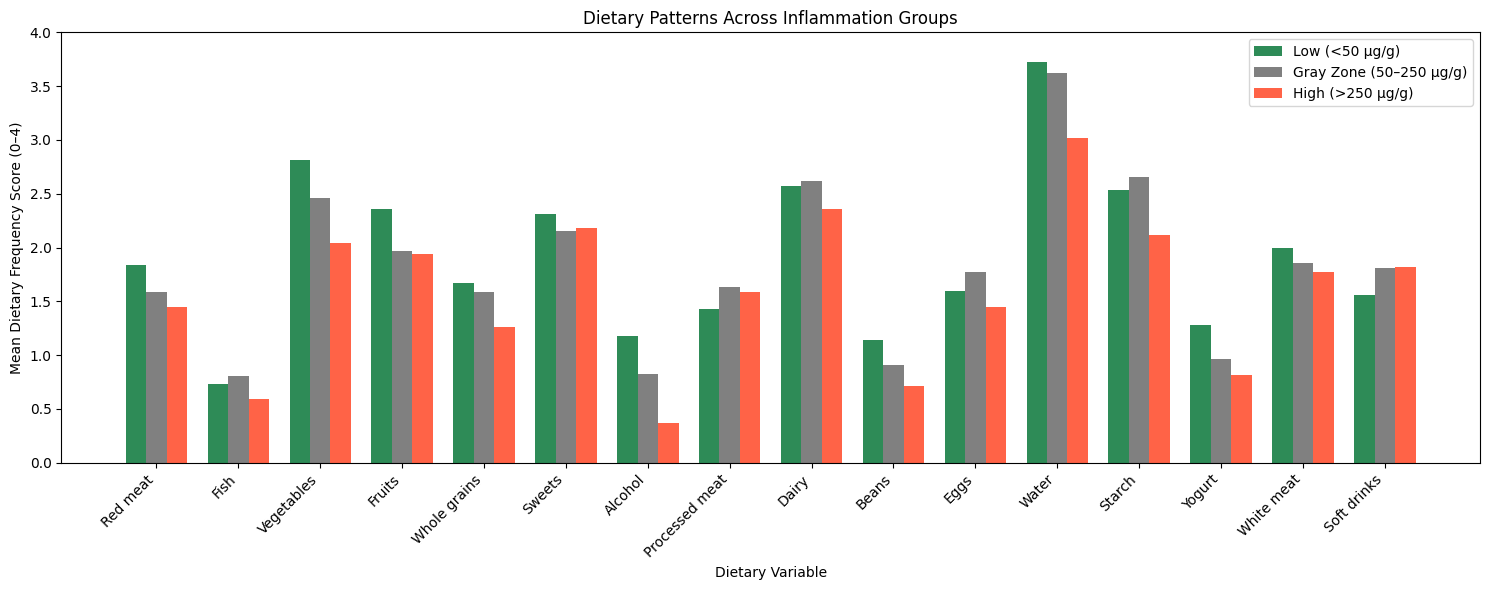

In [15]:
import matplotlib.pyplot as plt
import numpy as np

group_order = ["Low", "Gray Zone", "High"]

diet_by_inflammation = (
    df_clean
    .groupby("inflammation_level", observed=True)[dietary_cols]
    .mean()
    .reindex(group_order)
)

food_short = [
    "Red meat", "Fish", "Vegetables", "Fruits",
    "Whole grains", "Sweets", "Alcohol", "Processed meat",
    "Dairy", "Beans", "Eggs", "Water",
    "Starch", "Yogurt", "White meat", "Soft drinks"
]

x = np.arange(len(food_short))
width = 0.25

fig, ax = plt.subplots(figsize=(15, 6))

ax.bar(
    x - width,
    diet_by_inflammation.loc["Low"],
    width,
    label="Low (<50 μg/g)",
    color="seagreen"
)

ax.bar(
    x,
    diet_by_inflammation.loc["Gray Zone"],
    width,
    label="Gray Zone (50–250 μg/g)",
    color="gray"
)

ax.bar(
    x + width,
    diet_by_inflammation.loc["High"],
    width,
    label="High (>250 μg/g)",
    color="tomato"
)

ax.set_title("Dietary Patterns Across Inflammation Groups")
ax.set_xlabel("Dietary Variable")
ax.set_ylabel("Mean Dietary Frequency Score (0–4)")
ax.set_xticks(x)
ax.set_xticklabels(food_short, rotation=45, ha="right")
ax.set_ylim(0, 4)
ax.legend()

plt.tight_layout()
plt.show()

#NHANES

# download the dataset

In [16]:
# ============================
# 1. Download NHANES 2009-2010 datasets
# ============================

import pandas as pd
import os

# Create folder
!mkdir -p NHANES_2009_2010

# Download files
!wget -q -P NHANES_2009_2010 https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2009/DataFiles/DEMO_F.XPT
!wget -q -P NHANES_2009_2010 https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2009/DataFiles/DR1TOT_F.XPT
!wget -q -P NHANES_2009_2010 https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2009/DataFiles/MCQ_F.XPT

# Check downloaded files
!ls NHANES_2009_2010

DEMO_F.XPT  DR1TOT_F.XPT  MCQ_F.XPT


# read the files

In [17]:
# ============================
# 2. Read XPT files
# ============================

demo = pd.read_sas(
    "NHANES_2009_2010/DEMO_F.XPT"
)

diet = pd.read_sas(
    "NHANES_2009_2010/DR1TOT_F.XPT"
)

mcq = pd.read_sas(
    "NHANES_2009_2010/MCQ_F.XPT"
)


print("Demographics:", demo.shape)
print("Diet:", diet.shape)
print("MCQ:", mcq.shape)

Demographics: (10537, 43)
Diet: (10253, 166)
MCQ: (10109, 81)


In [18]:
print(demo.columns.tolist())

print(diet.columns.tolist())

print(mcq.columns.tolist())

['SEQN', 'SDDSRVYR', 'RIDSTATR', 'RIDEXMON', 'RIAGENDR', 'RIDAGEYR', 'RIDAGEMN', 'RIDAGEEX', 'RIDRETH1', 'DMQMILIT', 'DMDBORN2', 'DMDCITZN', 'DMDYRSUS', 'DMDEDUC3', 'DMDEDUC2', 'DMDSCHOL', 'DMDMARTL', 'DMDHHSIZ', 'DMDFMSIZ', 'INDHHIN2', 'INDFMIN2', 'INDFMPIR', 'RIDEXPRG', 'DMDHRGND', 'DMDHRAGE', 'DMDHRBR2', 'DMDHREDU', 'DMDHRMAR', 'DMDHSEDU', 'SIALANG', 'SIAPROXY', 'SIAINTRP', 'FIALANG', 'FIAPROXY', 'FIAINTRP', 'MIALANG', 'MIAPROXY', 'MIAINTRP', 'AIALANG', 'WTINT2YR', 'WTMEC2YR', 'SDMVPSU', 'SDMVSTRA']
['SEQN', 'WTDRD1', 'WTDR2D', 'DR1DRSTZ', 'DR1EXMER', 'DRABF', 'DRDINT', 'DR1DBIH', 'DR1DAY', 'DR1LANG', 'DR1MNRSP', 'DR1HELPD', 'DBQ095Z', 'DBD100', 'DRQSPREP', 'DRQSDIET', 'DRQSDT1', 'DRQSDT2', 'DRQSDT3', 'DRQSDT4', 'DRQSDT5', 'DRQSDT6', 'DRQSDT7', 'DRQSDT8', 'DRQSDT9', 'DRQSDT10', 'DRQSDT11', 'DRQSDT12', 'DRQSDT91', 'DR1TNUMF', 'DR1TKCAL', 'DR1TPROT', 'DR1TCARB', 'DR1TSUGR', 'DR1TFIBE', 'DR1TTFAT', 'DR1TSFAT', 'DR1TMFAT', 'DR1TPFAT', 'DR1TCHOL', 'DR1TATOC', 'DR1TATOA', 'DR1TRET', 'DR1T

#Merge the files

Information about each participant was stored across several datasets. Therefore, I merged the datasets using the unique participant identifier, SEQN.

In [19]:
# ============================
# 3. Merge datasets
# ============================

nhanes = demo.merge(
    diet,
    on="SEQN",
    how="inner"
)

nhanes = nhanes.merge(
    mcq,
    on="SEQN",
    how="left"
)

print(nhanes.shape)

nhanes.head()

(10253, 288)


,SEQN,SDDSRVYR,RIDSTATR,RIDEXMON,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDAGEEX,RIDRETH1,DMQMILIT,...,MCQ240T,MCQ240U,MCQ240V,MCQ240W,MCQ240X,MCQ240Y,MCQ240Z,MCQ300A,MCQ300B,MCQ300C
0,51624.0,6.0,2.0,1.0,1.0,34.0,409.0,410.0,3.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0,2.0
1,51625.0,6.0,2.0,2.0,1.0,4.0,49.0,50.0,5.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,51626.0,6.0,2.0,1.0,1.0,16.0,202.0,202.0,4.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN
3,51627.0,6.0,2.0,1.0,1.0,10.0,131.0,132.0,4.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,NaN
4,51628.0,6.0,2.0,2.0,2.0,60.0,722.0,722.0,4.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,1.0


# Store the merged file

In [20]:
nhanes.to_csv(
    "NHANES_2009_2010_merged.csv",
    index=False
)

print("Saved!")

Saved!


In [21]:
df1 = pd.read_csv("NHANES_2009_2010_merged.csv")

In [22]:
!wget -q -P NHANES_2009_2010 https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2009/DataFiles/CRP_F.XPT
crp = pd.read_sas(
    "NHANES_2009_2010/CRP_F.XPT"
)

df1 = df1.merge(
    crp,
    on="SEQN",
    how="left"
)

In [23]:
df1.shape


(10253, 289)

# Distribution of CRP

C-reactive protein is another biomarker that can represent the level of inflammation for IBD patients.

In [24]:
df1["LBXCRP"].describe()

,LBXCRP
count,8299.000000
mean,0.338788
std,0.713707
min,0.010000
25%,0.040000
50%,0.130000
75%,0.350000
max,18.010000


#Visualization of distribution of CRP

In [25]:
crp_data = df1["LBXCRP"].dropna()

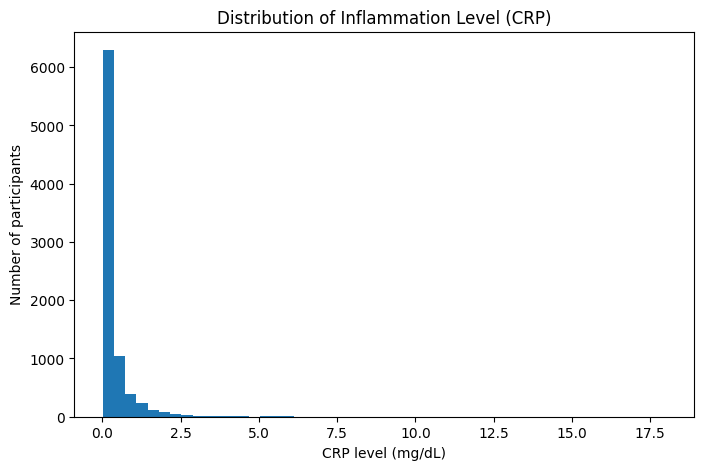

In [26]:


import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    crp_data,
    bins=50
)

plt.xlabel("CRP level (mg/dL)")
plt.ylabel("Number of participants")
plt.title("Distribution of Inflammation Level (CRP)")

plt.show()

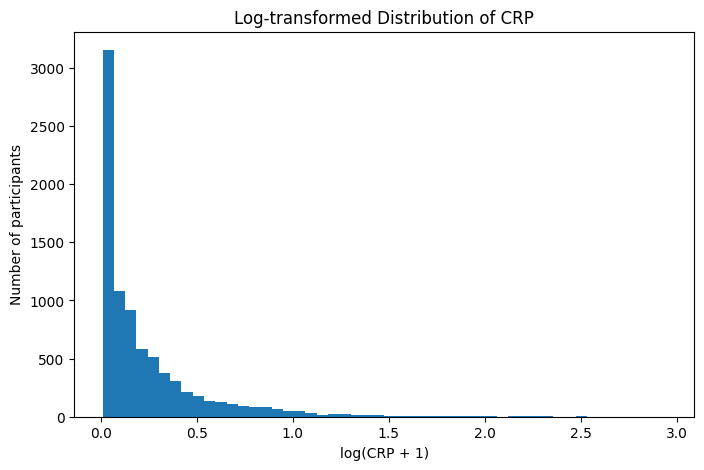

In [27]:
import numpy as np

plt.figure(figsize=(8,5))

plt.hist(
    np.log1p(crp_data),
    bins=50
)

plt.xlabel("log(CRP + 1)")
plt.ylabel("Number of participants")
plt.title("Log-transformed Distribution of CRP")

plt.show()